<table style="width:100%; float:center; background-color:#FFFFFF" align="left">
<tr>
<td style="text-align:left; background-color:#FFFFFF"></td>
<td style="text-align:right; background-color:#FFFFFF"><div>
<image src="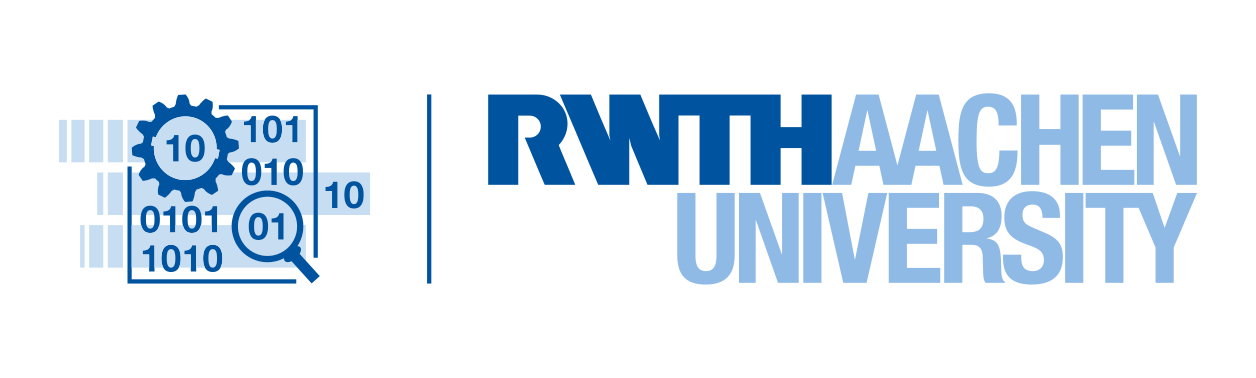" width="500">
    
</div>
</td></tr>
</table>

Prof. Dr. Sandra Geisler <br>
Anastasiia Belova, Soo-Yon Kim

May 12, 2025

<center>

<h1> Data Stream Management and Analysis <br />(Summer Term 2025)</h1>
    
<h1> Exercise 2</h1>
    
</center>

---
**Due until Monday, May 26 at 8:00am.
Please submit your solutions as a Jupyter notebook to Moodle.
Please do _not_ submit handwritten solutions! Your solutions should be submitted in groups of 4 students.**
Solutions to this exercise will be presented on Friday, May 30.

---

### Group members: [Luyang Huang, 466716], [Feiyu Wang, 460101], [Yansong Liu, 453322], [Xingjian Tian, 436949] 
#### Insert all group members by double-clicking on this cell.

## Task 1 (User-defined Aggregates) (6 pts)

Given is the following stream of sensor readings for different sensors. 



| timestamp | temperature | sensor |
| --- | --- | --- |
|1|21.2|env1|
|1|20.4|env3|
|2|21.1|env1|
|2|21.6|env2|
|2|22.1|env3|
|3|21.7|env3|
|3|20.3|env1|
|4|21.1|env2|
|4|21.7|env1|
|5|21.3|env2|
|5|20.2|env1|
|6|21.5|env2|

1\. Complete the UDA below that:

- Return the average temperature of the last 4 readings for each sensor (tumbling window based on 4 readings per sensor).
- Return `-1` for a sensor if it has not produced any reading in the last 4 time units. Then the internal state should be reset for
that sensor (e.g., if sensor `env1` has reading at timestamp 1, but then has no readings at timestamps 2, 3, 4, 5, return `-1` at timestamp 5 and reset its state).
- The UDA should be non-blocking.


In [ ]:
AGGREGATE sStream (sensor str, value double, ts Int): (str, double)
{ 
	TABLE state(sName str, sum double, last_ts Int, count Int);
	
	INITIALIZE : {
        INSERT INTO state VALUES (sensor, value, ts, 1);
	}
	
	ITERATE: {
        INSERT INTO state values (sensor, 0, ts, 0)
            WHERE NOT EXISTS
            (SELECT * FROM state WHERE sName = sensor)
        UPDATE state
            SET count += 1, last_ts = ts, sum += value
            WHERE sName = sensor;
		INSERT INTO RETURN
            SELECT sName, sum/count FROM state
            WHERE count = 4;
        UPDATE state
            SET count = 0, sum = 0
            WHERE count = 4;
        INSERT INTO RETURN
            SELECT sName, -1 FROM state
            WHERE ts - last_ts >= 4;
        UPDATE state
            SET count = 0, sum = 0
            WHERE ts - last_ts >= 4;
	}
	
	TERMINATE : {
 
	}
}

2\. At timestamp $\tau_6$, what is the current content of **the internal state table**?

| sName | sum | last_ts | count |
| --- | --- | ------- | ----- |
| env1|62.2 |5        |3      |
| env2|63.9 |6        |3      |
| env3|21.7 |3        |1      |

<div class = "alert alert-success">

2. Your values are incorrect -1.5pt

__4.5/6__
</div>

## Task 2 (Streamlog) (6 pts)

1\. Formulate an alert rule `PriceAlert(T,A,B)` for the simplified Binance stream `binance(datetime,ask,bid)` with sequential Streamlog rules and not strictly sequential for the following query:

The alert should be issued with the latest timestamp, ask, and bid as soon as the price difference between 'ask' and 'bid' (absolute value) is smaller or equal than 2 Euros and bid is higher than 5 Euros for all stream elements which arrived in the last 2 time units (i.e., including the current timestamp; all timestamps are defined in these time units). The alert rule is evaluated with each incoming element.

PriceAlert(T,A,B) :- binance(T,A,B), binance(T1,A1,B1),ABS(A,B), ABS(A1,B1), B1>5,B>5,T1<T.<br>
ABS(X,Y) :- X-Y <= 2, X-Y>=0.<br>
ABS(X,Y) :- Y-X <= 2, Y-X>=0.<br>

2\. Check your rules with the query? PriceAlert(T,A,B) for the following fact stream and write down an example evaluation of the rules (see Ch.2, slide 58 how to evaluate a rule). What is the query result? 

binance(1,2,2), binance(2,2,4), binance(3,5,6), binance(4,5,7) 

Alert is issued when binance(3,5,6) and binance(4,5,7) are in window.<br>
Condition 1: price difference between 'ask' and 'bid'(absolute value) is smaller or equal than 2 Euros
Only bids in these two stream elements are higher than 5.<br>
Condition 2: bid is higher than 5 Euros for all stream elements which arrived in the last 2 time units.<br>
binance(1,2,2) and binance(2,2,4) do not satisfy condition 2.<br>
binance(2,2,4) and biance(3,5,6) do not satisfy condition 2.

3\. Decide if the following program is sequential and explain in detail your decision. 

p(T,Z) $\leftarrow$ t(T,Z), $\neg$ n(T1,X), T1 < T

n(T,B) $\leftarrow$ l(T,L)

t(T,Y) $\leftarrow$ j(T1,W), T1 < T

There is no timestamp in n(T,B), it is sequential.<br>
For t(T,Y), the timestamp of j(T1,W) is < than timestamp of head. So t(T,Y) is sequential.<br>
For p(T,Z), its negated goals n(T1,X) is strictly sequenctial and the timestamp of n(T1,X) is < than timestamp of head. Besides, t(T,Y) is sequential. So p(T,Z) is sequential.

<div class = "alert alert-success">

__6/6__
</div>

## Task 3 (Logical Query Optimization) (4 pts)

Consider the following two streams *PersonInMotion* and *Environment*, and the relation *PersonData* as well as their schemas:

`PersonInMotion(ts,personid, heartrate,region)` (abbreviated `P`)  <br>
`Environment(ts,temperature,humidity,region, tacc, hacc)`  (abbreviated `E`) <br>
`PersonData(personid, name)`  (abbreviated `D`) <br>

1\. Formulate the following query in extended relational algebra.
Find all people, who visited a region in the last 24 hours, which had an average temperature of at least 28° during the last week.
Return their names sorted by the maximum heart rate during the last 24 hours.

$\pi_{name}(\tau_{MAX(heartrate)}D \bowtie_{D.personid = P.personid} 
 \gamma_{persionid}(W_{24 hours}(P)) \bowtie_{P.region=E.region}
\sigma_{AVG(temperature)>=28°}(W_{7_{days}}(E)) 
)$


2\. Discuss if the following query in relational algebra is optimal, given the following current selectivities:

* join PersonInMotion and Environment on timestamp and region: 0.6
* $\sigma_{region="Schwarzwald"}$: 0.1
* $\sigma_{tacc>67\%}$: 0.3

$\pi_{ts,humidity}(\sigma_{region="Schwarzwald"}(P \bowtie \sigma_{tacc>67\%} (E)))$

How would a decent query optimizer rewrite it?


$\pi_{ts,humidity}(\sigma_{region="Schwarzwald"} P\bowtie \sigma_{tacc>67\%} (E))$

<div class = "alert alert-success">

1. 
- $\sigma_{AVG(temperature)>=28°}$ and $\tau_{MAX(heartrate)}$ is not valid syntax -1pt
    - $\sigma_{\text{avgtemp} >28} \left( \gamma_{\text{region}, AVG(\text{temperature}) \rightarrow \text{avgtemp}}\left( W_{\text{1week}}(E) \right)\right)$
    - $\tau_{\text{mhr}}\left(  \gamma_{\text{pid}, MAX(\text{heartrate})\rightarrow \text{mhr}}\left(... \right)\right)$
- $\gamma_{persionid}$ is the operator for aggregations not projections -0.5pt

2.

- The region selection also needs to be applied to the environment relation before the tacc selection -0.5pt

__2/4__
</div>

## Task 4 (AND-OR DAGs) (8 pts)

We have given four tables/streams from a manufacturing monitoring as follows:

`machine(mno,height,width,model)`

`sensor(ts,humidity,mno)`

`product(pno,type,weight,mno)`

`configuration(cid,mno,c1,c2)`

The following two queries $Q1, Q2$ are executed. 

Q1: $\pi_{mno,model,humidity}((\sigma_{height>=100}(machine) \bowtie product)\bowtie sensor)$

Q2: $\pi_{mno,model,humidty}((\sigma_{height>50}(machine) \bowtie sensor)\bowtie configuration)$

1. Draw the single initial AND-OR DAGs for both queries. 

2. Draw the expanded AND-OR DAG incl. the links and nodes for all alternatives for both queries (use a different color for these links and nodes).

3. Discuss what can be shared between the two queries and why.

4. Reflecting your thoughts from 3., draw the corresponding unified AND-OR DAG.

1. 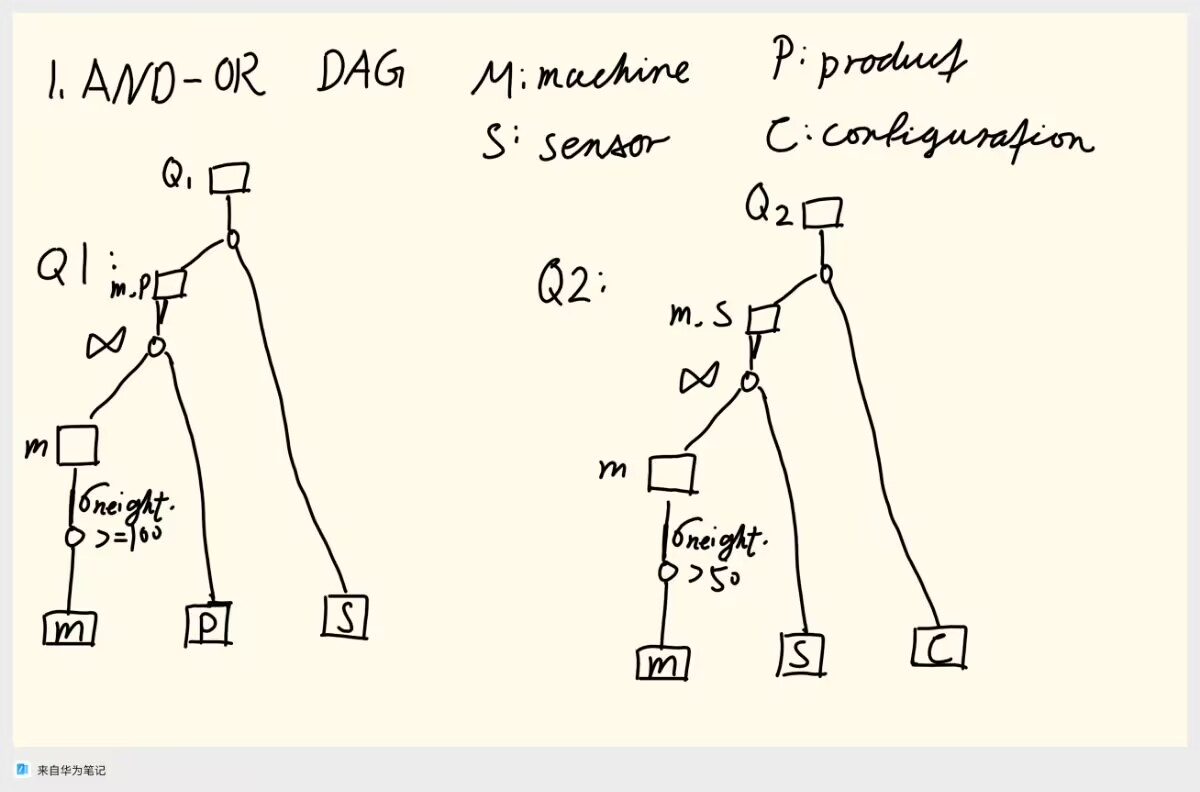
2. 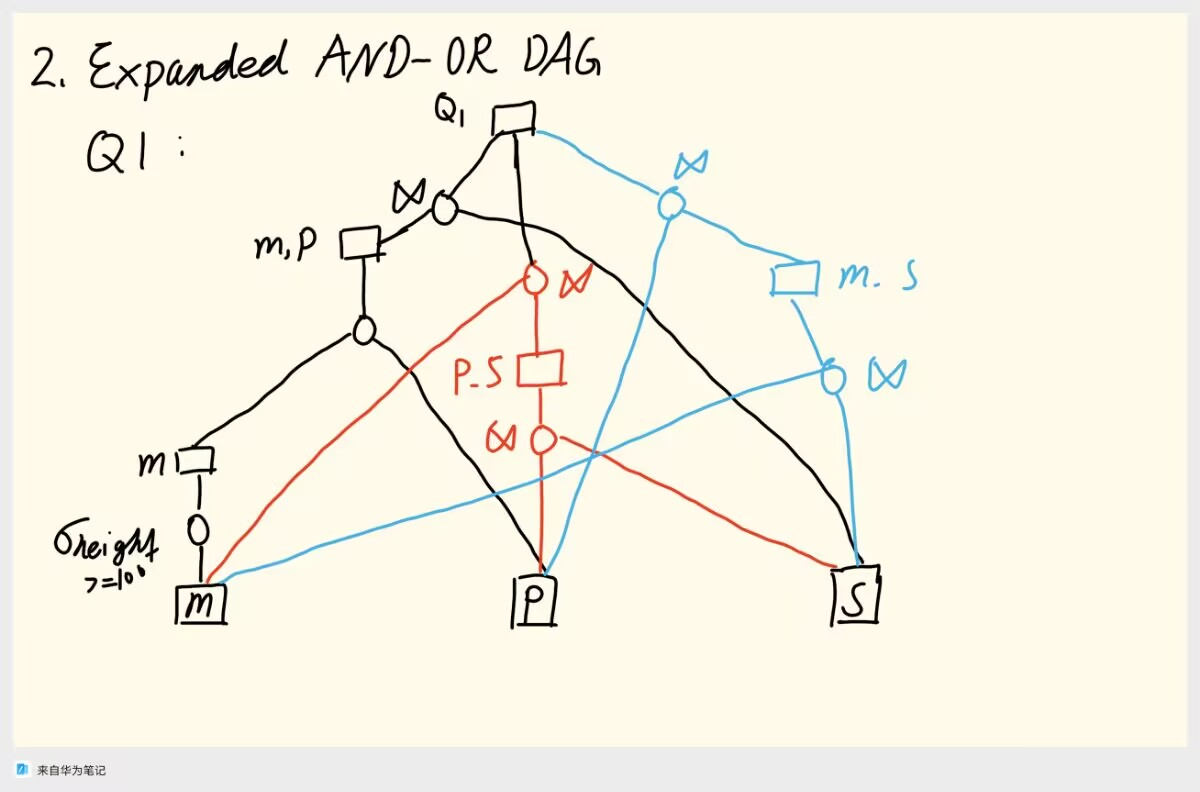
   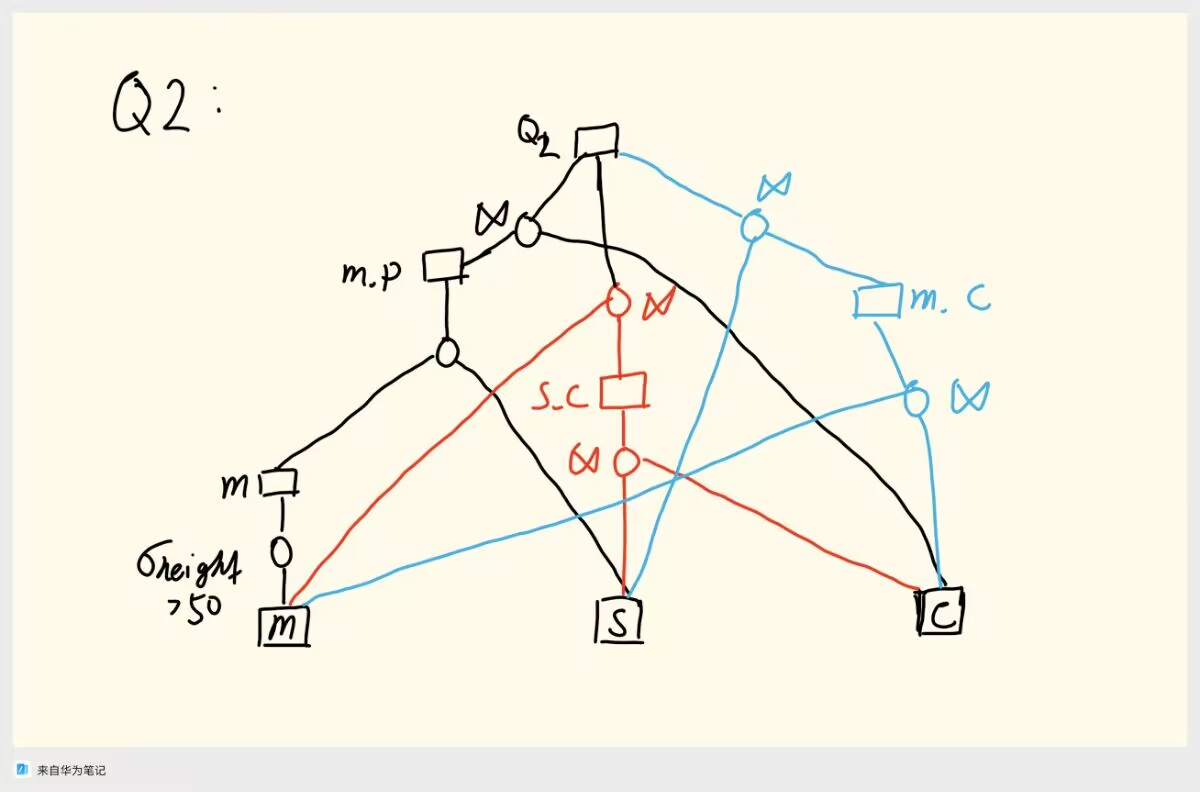
3. Selection in table machine. Join operation between machine and sensor, but it is quite expensive to further do selection in Q1 after join operation shared in Q2.
4. 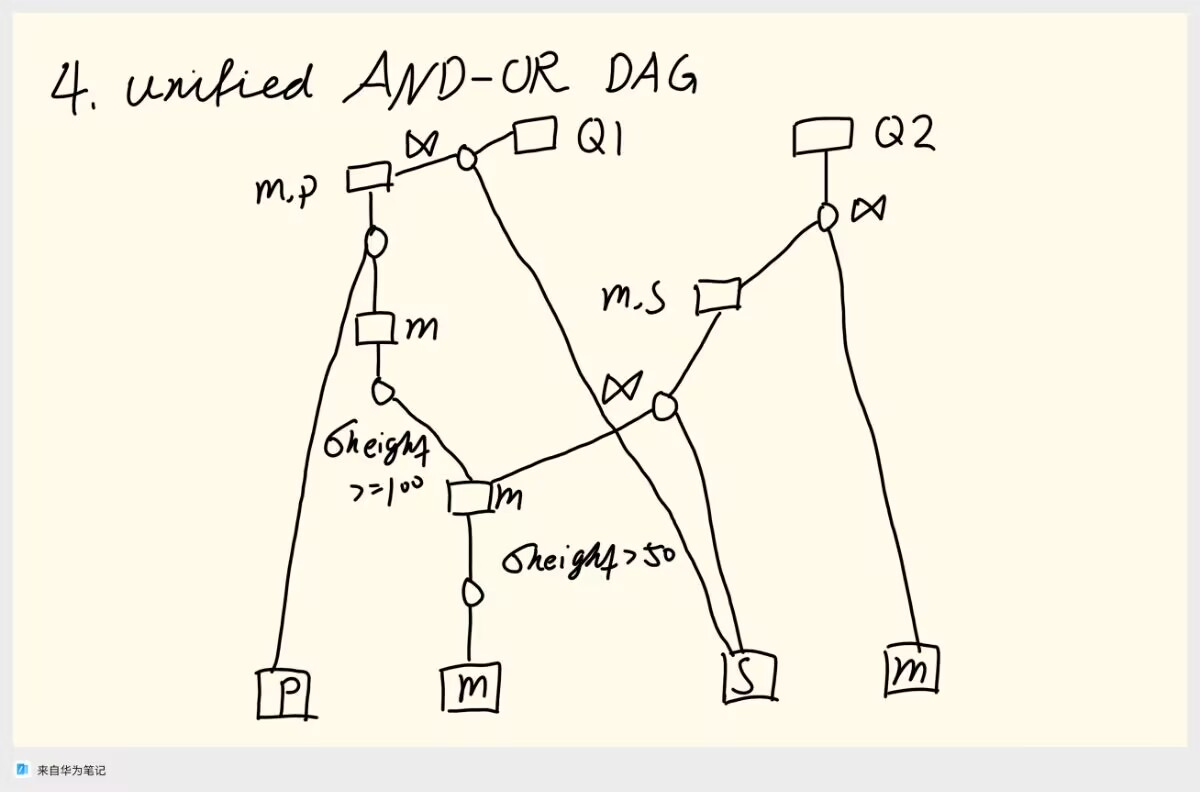

<div class = "alert alert-success">

2. 
- Your expanded DAGs do not cover all possible execution paths -0.5pt


4. 

- The Unified DAG has one root -1pt
- Configuration Relation is missing -0.5pt

__6/8__
</div>